In [152]:
import numpy as np
import matplotlib.pyplot as plt

In [153]:
# Function to compute MMSE for one round
def compute_mmse(B, H, x, snr_db):
    n = B.shape[0]
    BH = B * H
    signal = BH @ x
    P_signal = np.sum(x**2) / n
    snr_linear = 10 ** (snr_db / 10)
    P_noise = P_signal / snr_linear
    z = np.random.normal(0, np.sqrt(P_noise), size=(n, 1))
    y = signal + z
    target = np.sum(x)
    mmse = np.sum((y - target) ** 2) / n
    return mmse

In [154]:
def norm(arr):
    return np.sum(arr * arr, axis=0)

In [155]:
# Dimensions
no_of_sources=5
no_of_slots=4
P_total = 2.5
max_iters = 1000
snr=50  #from o to snr

In [156]:
snrs = np.arange(0, snr+1)
mmse_vals = []
for snr_db in snrs: 
    # print("B=",B,"\n")
    lambda_reg = 1.0      # Initial value of lambda
    eta = 0.01           # learning rate for B
    eta_lambda = 0.1     # learning rate for lambda
    tol = 1e-6
    
    # --- Random initialization ---
    B = np.random.randn(no_of_slots, no_of_sources)  # Initial B value
    np.random.seed(3)
    H = np.random.randn(no_of_slots, no_of_sources)
    x = np.random.uniform(-1, 1, size=(no_of_sources, 1))  # Uniform distribution between -1 and 1
    z = np.random.randn(no_of_slots, 1)


    for iter in range(max_iters):
        BH = B * H
        y = BH @ x +z  - np.sum(x)
        grad = 2 * (y @ x.T) * H + 2 * lambda_reg * B

        # Gradient step
        B_new = B - eta * grad
        colwise_norms = norm(B_new)

        # Make a copy to apply corrections 
        B_new1 = B_new.copy()

        # Check if any column has a squared norm greater than P_total
        if any(colwise_norms > P_total):      
            for i in range(B_new.shape[1]):  # Iterate over each column
                if colwise_norms[i] > P_total:
                    scaling_factor = np.sqrt(P_total / colwise_norms[i])
                    B_new1[:, i] *= scaling_factor
                    # print(norm(B_new1[:, i]) > P_total)  # Should print False

            # Dual update: Based on the total column norms exceeding P_total
            total_col_sum = np.sum(colwise_norms)
            lambda_reg += eta_lambda * (total_col_sum - P_total)
            lambda_reg = max(0, lambda_reg)

        # Convergence check
        if np.linalg.norm(B_new1 - B, ord='fro') < tol:
            # print(f"Converged at iteration {iter}")
            break

        # Update B
        B = B_new1

        mmse_list = [compute_mmse(B, H, x, snr_db) for _ in range(max_iters)]
    mmse_vals.append(np.mean(mmse_list))
    
print("mse",mmse_vals)

mse [0.4330678645651997, 0.3841719800292802, 0.35889501861654105, 0.30387680615497636, 0.2882922966387142, 0.260053564470428, 0.25415733164834386, 0.2384717302040004, 0.2214201588079885, 0.20894225090905352, 0.21567036803129047, 0.21347392893836417, 0.20884328713523778, 0.2143636845747211, 0.19477242343630438, 0.1909727332408698, 0.19340830433690298, 0.19613501170045294, 0.18815064216911082, 0.18979823585046376, 0.18640378502747923, 0.1975309945718141, 0.18983647277046087, 0.18975808869282662, 0.1886004582889638, 0.18558759179989517, 0.2046136459526745, 0.19154682716675656, 0.17977236001960206, 0.1875302775369861, 0.18592489795210446, 0.19890488907115464, 0.19342125721300665, 0.19424991862374322, 0.18694394826071134, 0.21081689489855251, 0.19492476356753882, 0.1948874650973322, 0.1868706208649898, 0.2107838073695026, 0.19484856633103367, 0.194854870886288, 0.1868379089730325, 0.2107733463850785, 0.19480894777386346, 0.19484121457678125, 0.18682266533483677, 0.2107708925687426, 0.194787

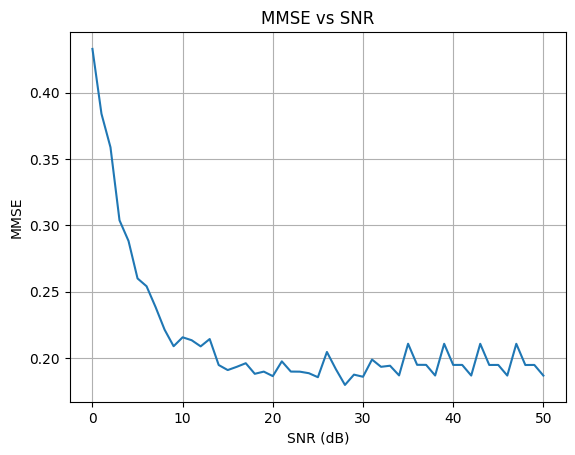

In [157]:
# Plot
plt.plot(snrs, mmse_vals)
plt.xlabel('SNR (dB)')
plt.ylabel('MMSE')
plt.title('MMSE vs SNR')
plt.grid(True)
plt.show()